In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

In [61]:
df.shape

(5000, 12)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [63]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [64]:
df.duplicated().sum()

0

In [65]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [66]:
df.select_dtypes("number").head(10)

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
0,10001,1102,7,373.65,0.28,10,4.7,1883.20
1,10002,1435,7,47.74,0.09,6,3.9,304.10
2,10003,1860,3,311.28,0.31,6,2.5,644.35
3,10004,1270,5,524.47,0.02,6,1.6,2569.90
4,10005,1106,5,139.87,0.33,4,4.9,468.56
5,10006,1071,2,264.44,0.20,3,3.3,423.10
6,10007,1700,6,564.60,0.23,1,1.8,2608.45
7,10008,1020,6,265.71,0.13,2,3.7,1387.01
8,10009,1614,6,224.65,0.27,2,1.4,983.97
9,10010,1121,4,272.71,0.06,10,4.5,1025.39


In [67]:
df.select_dtypes("object").tail(10)

,order_date,product_category,region,payment_method
4990,8/31/2035,Home,East,Card
4991,9/1/2035,Home,North,COD
4992,9/2/2035,Home,North,Wallet
4993,9/3/2035,Electronics,West,COD
4994,9/4/2035,Home,South,Card
4995,9/5/2035,Clothing,West,COD
4996,9/6/2035,Beauty,North,COD
4997,9/7/2035,Beauty,West,Wallet
4998,9/8/2035,Electronics,South,COD
4999,9/9/2035,Home,East,COD


In [68]:
with pd.option_context("float_format", "{:.2f}".format): 
    display(df.describe())

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12500.50,1505.70,4.04,308.42,0.18,6.12,2.97,1021.96
std,1443.52,290.84,2.02,169.26,0.10,3.15,1.16,825.58
min,10001.00,1000.00,1.00,15.15,0.00,1.00,1.00,11.21
25%,11250.75,1253.00,2.00,161.90,0.09,3.00,2.00,354.53
50%,12500.50,1510.00,4.00,309.89,0.18,6.00,3.00,796.65
75%,13750.25,1761.00,6.00,455.56,0.27,9.00,4.00,1515.69
max,15000.00,1999.00,7.00,599.96,0.35,11.00,5.00,4119.33


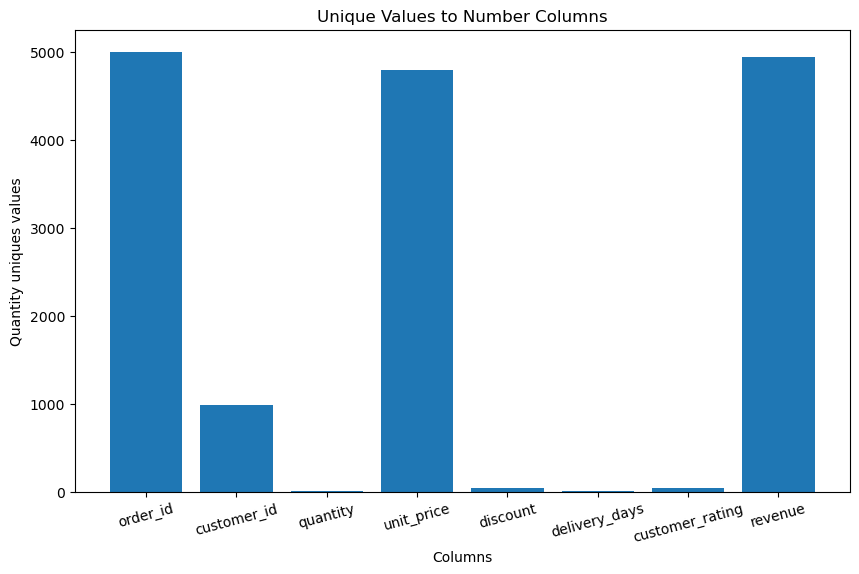

In [69]:
data_numbers = df.select_dtypes("number").nunique()

plt.figure(figsize= (10,6))
plt.bar(data_numbers.index, data_numbers.values)
plt.title("Unique Values to Number Columns")
plt.xlabel("Columns")
plt.ylabel("Quantity uniques values")
plt.xticks(rotation = 15)
plt.savefig("imgs/unique_values.png", bbox_inches="tight", facecolor="white")
plt.show()
plt.show()

In [70]:
df.select_dtypes("object").nunique()


order_date          5000
product_category       4
region                 4
payment_method         3
dtype: int64

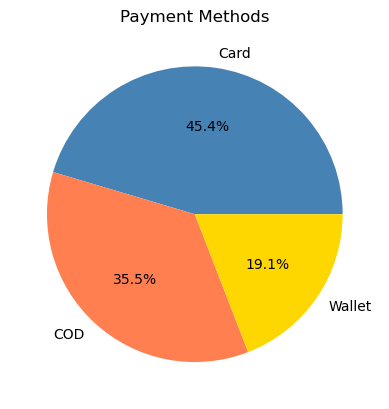

In [71]:
df_payment = df["payment_method"].value_counts()
colors = ["steelblue", "coral", "gold"]
plt.pie(df_payment.values, labels=df_payment.index, autopct = "%1.1f%%", colors = colors)
plt.title("Payment Methods")
plt.savefig("imgs/payment_methods.png", bbox_inches="tight", facecolor="white")
plt.show()



In [72]:
df["payment_method"].value_counts()

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [73]:
df["payment_method"].unique()

array(['Wallet', 'Card', 'COD'], dtype=object)

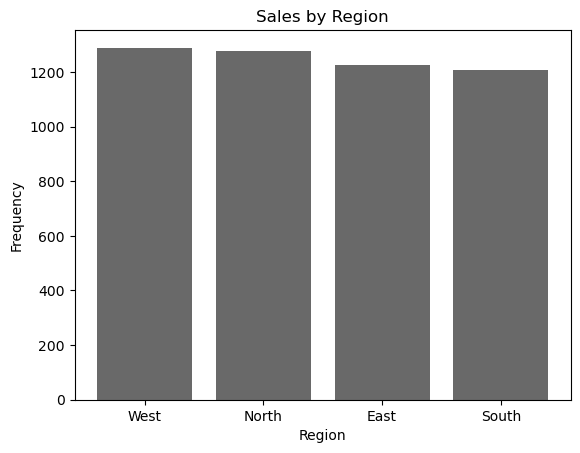

In [102]:
df_region = df["region"].value_counts()

plt.bar(df_region.index, df_region.values, color="dimgray")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Frequency")
plt.savefig("imgs/region.png", bbox_inches="tight", facecolor="white")
plt.show()

In [75]:
df["region"].value_counts()

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64

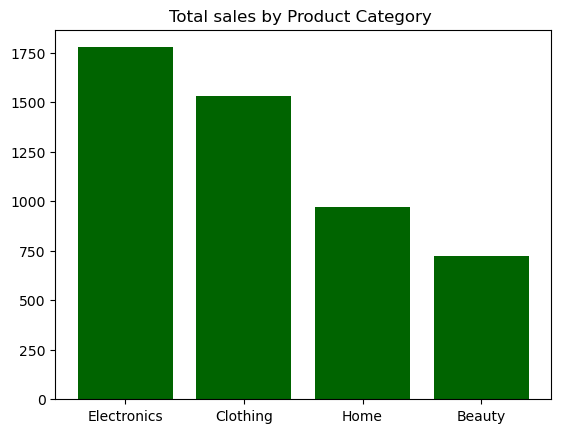

In [76]:
df_category = df["product_category"].value_counts()

plt.bar(df_category.index, df_category.values, color="darkgreen")
plt.title("Total sales by Product Category ")
plt.savefig("imgs/product_category.png", bbox_inches="tight", facecolor="white")
plt.show()

In [77]:
prod_category = (df["product_category"].value_counts())
for i in range(len(prod_category)):
    print(f"{i + 1} - {prod_category.index[i]}: {prod_category.values[i]}")

1 - Electronics: 1777
2 - Clothing: 1531
3 - Home: 969
4 - Beauty: 723


In [78]:
df.iloc[0: 10, 1:10]

,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days
0,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10
1,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6
2,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6
3,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6
4,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4
5,1/6/2022,1071,Electronics,West,2,264.44,0.20,Card,3
6,1/7/2022,1700,Clothing,South,6,564.60,0.23,Card,1
7,1/8/2022,1020,Beauty,North,6,265.71,0.13,Card,2
8,1/9/2022,1614,Clothing,South,6,224.65,0.27,Card,2
9,1/10/2022,1121,Clothing,West,4,272.71,0.06,Card,10


In [79]:
df.loc[0:10]

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
5,10006,1/6/2022,1071,Electronics,West,2,264.44,0.20,Card,3,3.3,423.10
6,10007,1/7/2022,1700,Clothing,South,6,564.60,0.23,Card,1,1.8,2608.45
7,10008,1/8/2022,1020,Beauty,North,6,265.71,0.13,Card,2,3.7,1387.01
8,10009,1/9/2022,1614,Clothing,South,6,224.65,0.27,Card,2,1.4,983.97
9,10010,1/10/2022,1121,Clothing,West,4,272.71,0.06,Card,10,4.5,1025.39


In [80]:
df.loc[0:10, ["product_category", "quantity", "unit_price"]]

,product_category,quantity,unit_price
0,Beauty,7,373.65
1,Clothing,7,47.74
2,Beauty,3,311.28
3,Electronics,5,524.47
4,Clothing,5,139.87
5,Electronics,2,264.44
6,Clothing,6,564.60
7,Beauty,6,265.71
8,Clothing,6,224.65
9,Clothing,4,272.71


In [81]:
df.loc[0:10, ["quantity", "unit_price"]]

,quantity,unit_price
0,7,373.65
1,7,47.74
2,3,311.28
3,5,524.47
4,5,139.87
5,2,264.44
6,6,564.60
7,6,265.71
8,6,224.65
9,4,272.71


In [82]:
df.loc[0:10, ["order_date", "region","product_category", "payment_method"]]

,order_date,region,product_category,payment_method
0,1/1/2022,South,Beauty,Wallet
1,1/2/2022,South,Clothing,Card
2,1/3/2022,East,Beauty,COD
3,1/4/2022,West,Electronics,Wallet
4,1/5/2022,West,Clothing,Wallet
5,1/6/2022,West,Electronics,Card
6,1/7/2022,South,Clothing,Card
7,1/8/2022,North,Beauty,Card
8,1/9/2022,South,Clothing,Card
9,1/10/2022,West,Clothing,Card


In [83]:
df[df["customer_rating"] >= 3]

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
5,10006,1/6/2022,1071,Electronics,West,2,264.44,0.20,Card,3,3.3,423.10
7,10008,1/8/2022,1020,Beauty,North,6,265.71,0.13,Card,2,3.7,1387.01
...,...,...,...,...,...,...,...,...,...,...,...,...
4991,14992,9/1/2035,1183,Home,North,2,353.46,0.28,COD,9,4.9,508.98
4992,14993,9/2/2035,1110,Home,North,2,285.82,0.03,Wallet,11,4.9,554.49
4994,14995,9/4/2035,1507,Home,South,6,25.85,0.12,Card,5,3.1,136.49
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06


In [84]:
df[df["customer_rating"] < 3].head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
6,10007,1/7/2022,1700,Clothing,South,6,564.60,0.23,Card,1,1.8,2608.45
8,10009,1/9/2022,1614,Clothing,South,6,224.65,0.27,Card,2,1.4,983.97
10,10011,1/11/2022,1466,Clothing,West,6,318.88,0.02,COD,7,1.4,1875.01


In [85]:
df[df["delivery_days"] >=5][["order_date", "delivery_days"]].head(5)

,order_date,delivery_days
0,1/1/2022,10
1,1/2/2022,6
2,1/3/2022,6
3,1/4/2022,6
9,1/10/2022,10


In [86]:
df[df["region"] == "North"][["order_date", "product_category", "region", "payment_method", "delivery_days"]].head(10)

,order_date,product_category,region,payment_method,delivery_days
7,1/8/2022,Beauty,North,Card,2
16,1/17/2022,Clothing,North,Wallet,11
21,1/22/2022,Home,North,Card,3
24,1/25/2022,Clothing,North,COD,4
26,1/27/2022,Home,North,COD,1
27,1/28/2022,Electronics,North,Card,8
28,1/29/2022,Clothing,North,Wallet,5
30,1/31/2022,Electronics,North,Card,1
32,2/2/2022,Electronics,North,Wallet,9
33,2/3/2022,Home,North,Card,9


In [87]:
print(f"{df["delivery_days"].mean():.2f}") 

6.12


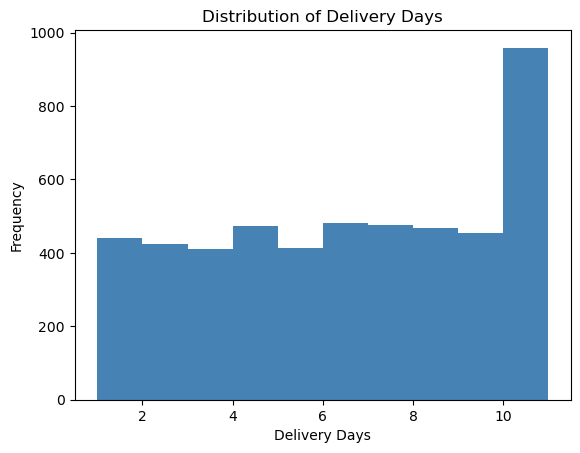

In [88]:
plt.hist(df["delivery_days"], color="steelblue")
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.savefig("imgs/delivery_days.png", bbox_inches="tight", facecolor="white")
plt.show()

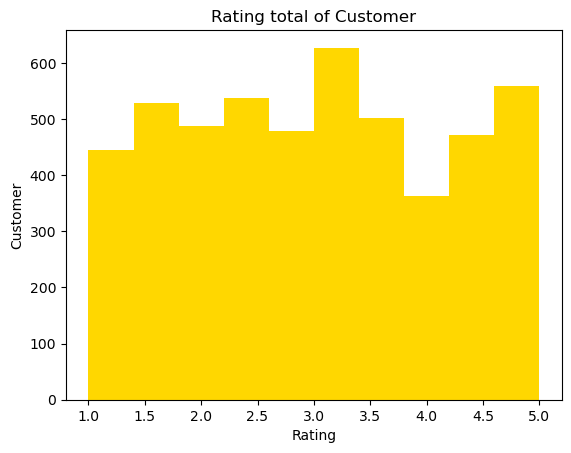

In [89]:
df["customer_rating"].mean()
plt.hist(df["customer_rating"], color="gold")
plt.title("Rating total of Customer")
plt.xlabel("Rating")
plt.ylabel("Customer")
plt.savefig("imgs/customer_rating.png", bbox_inches="tight", facecolor="white")
plt.show()

In [90]:
print(f"{df["customer_rating"].mean():.2f}")

2.97


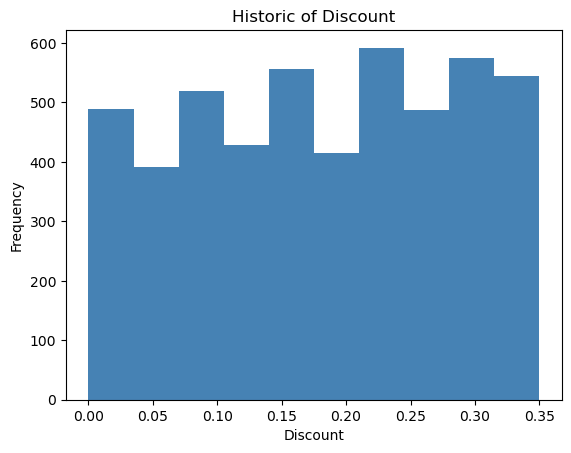

In [91]:
plt.hist(df["discount"], color="steelblue")
plt.title("Historic of Discount")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.savefig("imgs/discount.png", bbox_inches="tight", facecolor="white")
plt.show()


In [92]:
print(f"{df["discount"].mean()}")

0.179984


In [93]:
df[df["unit_price"] > 599]


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
135,10136,5/16/2022,1520,Home,South,3,599.32,0.29,COD,10,2.7,1276.55
712,10713,12/14/2023,1042,Electronics,West,4,599.01,0.25,COD,4,3.9,1797.03
2053,12054,8/16/2027,1607,Electronics,East,5,599.89,0.11,Card,4,4.9,2669.51
2228,12229,2/7/2028,1972,Home,East,4,599.68,0.21,Card,2,4.1,1894.99
2701,12702,5/25/2029,1951,Electronics,West,3,599.96,0.15,COD,1,1.2,1529.90
3690,13691,2/8/2032,1472,Electronics,North,2,599.21,0.29,Card,7,2.5,850.88
3755,13756,4/13/2032,1515,Electronics,West,7,599.50,0.23,Wallet,4,1.9,3231.30


In [94]:
better_sale = np.argmax(df["unit_price"])
print(f"Category: {df["product_category"][better_sale]}\nValue: ${df["unit_price"][better_sale]}")

Category: Electronics
Value: $599.96


In [95]:
worst_sale = np.argmin(df["unit_price"])
print(f"Category: {df["product_category"][worst_sale]}\nValue: {df["unit_price"][worst_sale]}")

Category: Clothing
Value: 15.15


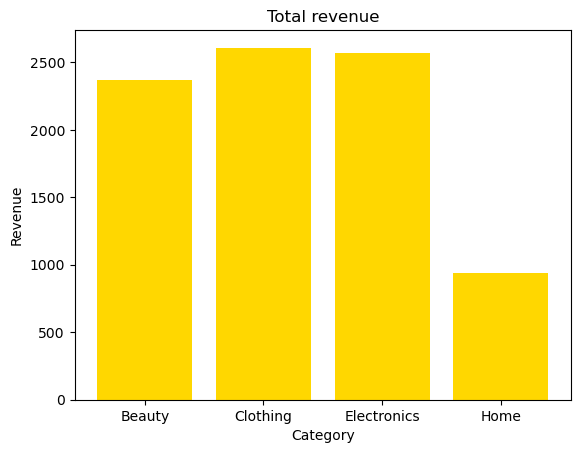

In [96]:
df_revenue = df["revenue"].head(20)
df_categ = df["product_category"].head(20)
plt.bar(df_categ, df_revenue, color="gold")
plt.title("Total revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.savefig("imgs/revenue.png", bbox_inches="tight", facecolor="white")
plt.show()

In [97]:
print(f"{df["revenue"].sum():,.2f}")

5,109,775.74


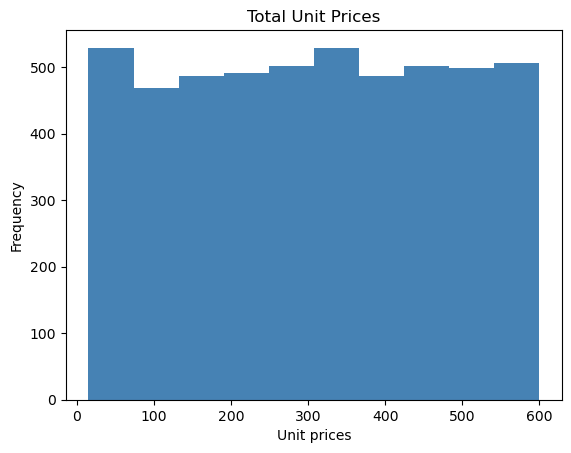

In [98]:

plt.hist(df["unit_price"], color="steelblue")
plt.title("Total Unit Prices")
plt.xlabel("Unit prices")
plt.ylabel("Frequency")
plt.savefig("imgs/unit_price.png", bbox_inches="tight", facecolor="white")
plt.show()


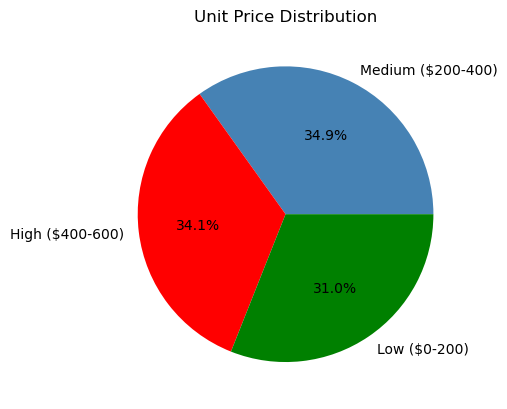

In [99]:
price_class = pd.cut(df["unit_price"], 
                     bins=[0, 200, 400, 600], 
                     labels=["Low ($0-200)", "Medium ($200-400)", "High ($400-600)"])

price_counts = price_class.value_counts()

color_pie = ["steelblue", "red", "green"]

plt.pie(price_counts.values, labels=price_counts.index, autopct="%1.1f%%", colors= color_pie)
plt.title("Unit Price Distribution")
plt.savefig("imgs/price_distribution.png", bbox_inches="tight", facecolor="white")
plt.show()

In [100]:
print(f"{df["unit_price"].mean():,.2f}")

308.42


In [101]:
prices = df["unit_price"].head(10)
for i in range(len(prices)):
   prices_condi =  np.where(prices >= 300, "High", "Low")
   print(f"${prices[i]}: {prices_condi[i]}")

$373.65: High
$47.74: Low
$311.28: High
$524.47: High
$139.87: Low
$264.44: Low
$564.6: High
$265.71: Low
$224.65: Low
$272.71: Low
